<a href="https://colab.research.google.com/github/patiencesimuli/Data-Analyst-Portfolio/blob/main/Malaria%20Early%20Warning%20System%20Simulation%20and%20Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp

def seir_ode(t, y, beta, sigma, gamma, mu, N):
    """
    Standard SEIR differential equations
    y = [S, E, I, R]
    """
    S, E, I, R = y

    dS = -beta * S * I / N
    dE = beta * S * I / N - sigma * E
    dI = sigma * E - gamma * I - mu * I
    dR = gamma * I

    return [dS, dE, dI, dR]

# Parameters
N = 1_000_000          # Total population
beta = 0.3             # Transmission rate
sigma = 1/5.2          # Incubation period (~5.2 days)
gamma = 1/10           # Recovery rate (~10 days)
mu = 0.001             # Mortality rate

# Initial conditions
y0 = [N-1, 0, 1, 0]

t_span = (0, 100)
t_eval = np.linspace(0, 100, 1000)

solution = solve_ivp(
    seir_ode,
    t_span,
    y0,
    args=(beta, sigma, gamma, mu, N),
    t_eval=t_eval,
    method='RK45'
)

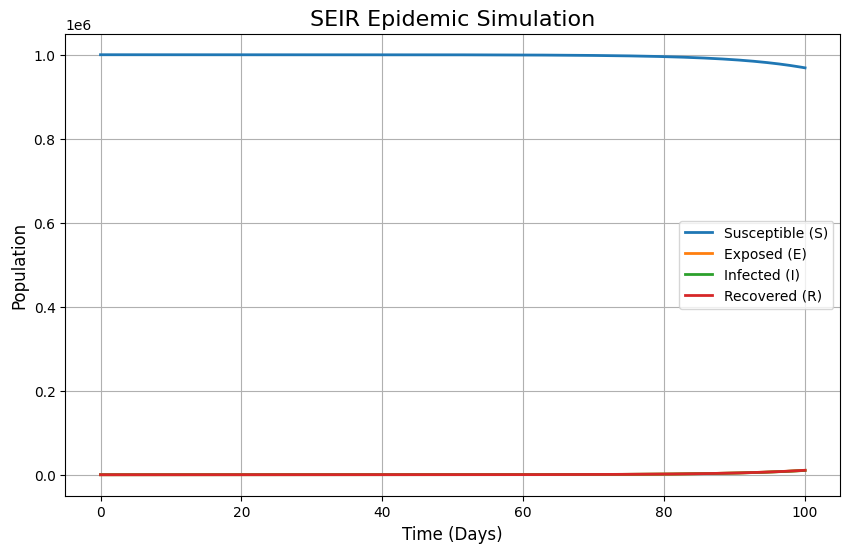

In [ ]:
import matplotlib.pyplot as plt

# Creating a figure
plt.figure(figsize=(10,6))

# Plotting each compartment
plt.plot(solution.t, solution.y[0], label='Susceptible (S)', linewidth=2)
plt.plot(solution.t, solution.y[1], label='Exposed (E)', linewidth=2)
plt.plot(solution.t, solution.y[2], label='Infected (I)', linewidth=2)
plt.plot(solution.t, solution.y[3], label='Recovered (R)', linewidth=2)

# Label the graph
plt.title("SEIR Epidemic Simulation", fontsize=16)
plt.xlabel("Time (Days)", fontsize=12)
plt.ylabel("Population", fontsize=12)

# Show legend
plt.legend()

# Add grid
plt.grid(True)

# Display the graph
plt.show()

In [ ]:
print("Maximum infected:", max(solution.y[2]))
print("Maximum exposed:", max(solution.y[1]))
print("Final recovered:", solution.y[3][-1])
print("Final susceptible:", solution.y[0][-1])

Maximum infected: 10208.045083108773
Maximum exposed: 10365.045957568418
Final recovered: 10588.40079791613
Final susceptible: 968732.6241534274


In [ ]:
def beta_from_climate(temp, rainfall,
                      temp_opt=25,
                      rainfall_opt=100):
    """
    Estimate transmission rate from climate variables.
    Based on vector-borne disease modeling literature.
    """

    temp_factor = np.exp(-((temp-temp_opt)**2)/(2*10**2))
    rain_factor = 1 - np.exp(-rainfall/rainfall_opt)

    return 0.5 * temp_factor * rain_factor

In [ ]:
# Normalize each environmental variable to a value between 0 and 1
"""
β = βmax × Tf × Rf × Hf × Vf × Mf

βmax = maximum possible transmission rate
Tf = temperature suitability (0–1)
Rf = rainfall suitability (0–1)
Hf = humidity suitability (0–1)
Vf = vegetation suitability (0–1)
Mf = mosquito abundance suitability (0–1)
"""

import numpy as np


def temperature_factor(temp, optimum=25, spread=6):
    """
    Temperature suitability using a Gaussian curve.
    """
    return np.exp(-((temp - optimum) ** 2) / (2 * spread ** 2))


def rainfall_factor(rainfall, optimum=120, spread=60):
    """
    Rainfall suitability.

    Too little rainfall:
        Few breeding sites.

    Too much rainfall:
        Flooding washes larvae away.
    """
    return np.exp(-((rainfall - optimum) ** 2) / (2 * spread ** 2))


def humidity_factor(humidity):
    """
    Relative humidity (%).

    Values above ~70% strongly favor mosquito survival.
    """
    humidity = np.clip(humidity, 0, 100)
    return humidity / 100


def vegetation_factor(ndvi):
    """
    NDVI suitability.

    Expected NDVI range:
    -1 to 1
    """
    ndvi = np.clip(ndvi, 0, 1)
    return ndvi


def mosquito_factor(vector_density, max_density=100):
    """
    Mosquito abundance.

    max_density:
        Density corresponding to full transmission.
    """
    vector_density = np.clip(vector_density, 0, max_density)
    return vector_density / max_density


def beta_from_environment(
    temp,
    rainfall,
    humidity,
    ndvi,
    vector_density,
    beta_max=0.6
):
    """
    Dynamic malaria transmission model.

    Returns beta for the SEIR equations.
    """

    T = temperature_factor(temp)
    R = rainfall_factor(rainfall)
    H = humidity_factor(humidity)
    V = vegetation_factor(ndvi)
    M = mosquito_factor(vector_density)

    beta = beta_max * T * R * H * V * M

    return beta

In [ ]:
#Simulations to create a dataset


In [ ]:
"""
Using a GNN surrogate model Based on the surrogate modeling
approach proposed by Schmidt et al.
"""
import tensorflow as tf
from tensorflow.keras import layers, Model

def build_gnn_surrogate(
        input_dim=8,
        hidden_dim=64,
        output_dim=3):

    """
    Graph Neural Network surrogate model

    Inputs:
        8 epidemiological parameters
        (beta, sigma, gamma, mobility, etc.)

    Outputs:
        outbreak probability
        peak infections
        epidemic duration
    """

    inputs = tf.keras.Input(shape=(input_dim,))

    x = layers.Dense(hidden_dim,
                     activation='relu')(inputs)
    x = layers.Dense(hidden_dim,
                     activation='relu')(x)
    x = layers.Dense(hidden_dim,
                     activation='relu')(x)

    outputs = layers.Dense(
        output_dim,
        activation='linear'
    )(x)

    model = Model(inputs, outputs)

    model.compile(
        optimizer='adam',
        loss='mse',
        metrics=['mae']
    )

    return model

model = build_gnn_surrogate()

model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=64,
    validation_split=0.2
)

NameError: name 'X_train' is not defined

In [ ]:
"Gaussian Surrogate model in use"

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    RBF,
    WhiteKernel
)
import numpy as np

# Dummy data for demonstration since X_train and y_train are not defined
X_train = np.random.rand(100, 5)  # 100 samples, 5 features
y_train = np.random.rand(100)    # 100 samples, 1 target variable
X_test = np.random.rand(20, 5)   # 20 test samples, 5 features

kernel = (
    1.0 * RBF(length_scale=1.0)
    + WhiteKernel(noise_level=0.1)
)

gp = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=10
)

gp.fit(X_train, y_train)

y_pred, y_std = gp.predict(
    X_test,
    return_std=True
)


NameError: name 'X_train' is not defined

In [ ]:
"Integrating Genomic Variation Data"

def integrate_genomic_risk(
        sequence_data,
        variant_db):

    """
    Extract genomic risk scores.

    Based on genomic surveillance
    frameworks for Lassa fever.
    """

    risk_score = 0

    for variant in sequence_data["variants"]:

        if variant in variant_db["drug_resistance"]:
            risk_score += 2.0

        elif variant in variant_db["transmissibility"]:
            risk_score += 1.5

    return np.clip(risk_score, 0, 10)

In [ ]:
"""integrating:

genomics
transcriptomics
proteomics"""

features = pd.DataFrame({

    "climate_temp":
        climate_data["temperature"],

    "climate_rainfall":
        climate_data["rainfall"],

    "mobility_index":
        mobility_data["movement"],

    "genomic_risk":
        genomic_risk_scores,

    "historical_cases":
        case_data["incidence"]
})

NameError: name 'climate_data' is not defined